In [1]:
import os
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from mypackages.eRDF import (butter_lowpass_filter,DataProcessor, 
                            read_discus_fit_file, remove_empty_strings,
                              optimize_constant, calculate_rw) 

from mypackages.plot_style import set_plot_style

set_plot_style()

In [2]:

# Path to the folder containing the files
path = "/home/ABTLUS/victor.secco/data_processing/EXP2PDF/DATA/In2O3/fqobs"

# Assuming file_names is already populated with the list of files
# Initialize an empty list to hold DataFrames
df_list = []

# Counter for naming columns
counter = 0

file_names = [x for x in os.listdir(path) if x.endswith("fqobs")]
file_names.sort()

# Loop through the files and process each one
for file in file_names:
    # Read the file into a DataFrame
    df = pd.read_csv(os.path.join(path, file), header=None, engine='python')
    df[0] = df[0].str.split(' ')
    df[0] = df[0].apply(remove_empty_strings)
    df[[0, 1]] = pd.DataFrame(df[0].tolist(), index=df.index)
    df = df.astype(float)

    df_dropped = df.drop(columns=[0])
    
    # Rename columns using the counter
    df_dropped.columns = [f'column_{counter + i}' for i in range(df_dropped.shape[1])]
    
    # Increment the counter for the next file's columns
    counter += df_dropped.shape[1]
    
    # Append the modified DataFrame to the list
    df_list.append(df_dropped)

# Concatenate all DataFrames in the list into a single DataFrame
final_df = pd.concat(df_list, axis=1)

df_cleaned = final_df.dropna()
df_cleaned = df_cleaned.T
# Optionally, display the final DataFrame or save it
print(df_cleaned)


                    0         1         2         3         4         5      \
column_0    3.078029e-321  0.410877  0.410395  0.409887  0.409341  0.408746   
column_1    5.459425e-321  0.242188  0.241559  0.240894  0.240182  0.239411   
column_2    5.365553e-321  0.299907  0.299000  0.298077  0.297133  0.296164   
column_3    5.291443e-321  0.254909  0.253827  0.252750  0.251683  0.250633   
column_4    5.370494e-321  0.290568  0.289105  0.287679  0.286311  0.285021   
...                   ...       ...       ...       ...       ...       ...   
column_155  3.171901e-321  0.226569  0.226640  0.226699  0.226744  0.226772   
column_156  3.127436e-321  0.276826  0.276407  0.275996  0.275601  0.275225   
column_157  3.152139e-321  0.267017  0.266508  0.266008  0.265522  0.265055   
column_158  3.166961e-321  0.214901  0.214644  0.214394  0.214155  0.213932   
column_159  3.152139e-321  0.362717  0.362636  0.362478  0.362211  0.361801   

               6         7         8         9     

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Standardizing the features
scaler = StandardScaler()
fq_scaled = scaler.fit_transform(df_cleaned)

# Instantiate the PCA model
pca = PCA(n_components=20)  # You can specify the number of components you want to retain

# Fit and transform the data
fq_pca = pca.fit_transform(fq_scaled)

# Convert the result to a DataFrame for easier handling
#fq_pca_df = pd.DataFrame(fq_pca, columns=['PC1', 'PC2'])

# Instantiate the PCA model
pca = PCA(n_components=20)  # You can specify the number of components you want to retain

# Fit and transform the data
pca.fit(fq_scaled)
fq_pca = pca.transform(fq_scaled)
# Convert the result to a DataFrame for easier handling
#fq_pca_df = pd.DataFrame(fq_pca, columns=['PC1', 'PC2'])

#plt.figure(figsize=(8, 6))
#plt.scatter(fq_pca_df['PC1'], fq_pca_df['PC2'])
#plt.xlabel('Principal Component 1')
#plt.ylabel('Principal Component 2')
#plt.title('PCA of fq DataFrame')
#plt.show()

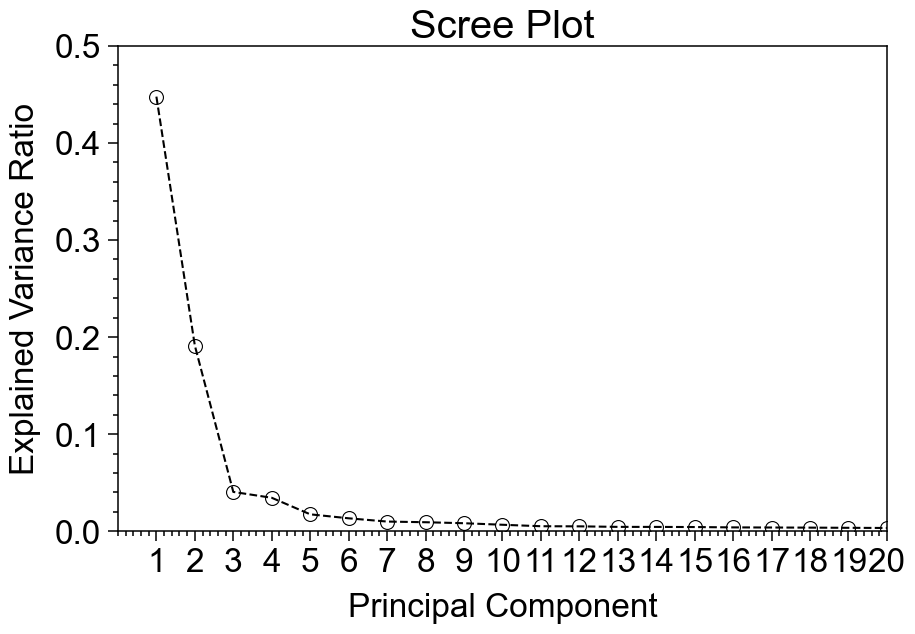

In [4]:
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

In [5]:
n_components = 2
pca = PCA(n_components=n_components)
fq_pca_reduced = pca.fit_transform(fq_scaled)

# Reconstruct the data from the selected components
fq_reconstructed = pca.inverse_transform(fq_pca_reduced)

# Reverse the standardization to get the data back to its original scale
fq_reconstructed_original_scale = scaler.inverse_transform(fq_reconstructed)

# Convert the reconstructed data back to a DataFrame (optional)
fq_reconstructed_df = pd.DataFrame(fq_reconstructed_original_scale, columns=df_cleaned.columns)

# Optionally, inspect the reconstructed DataFrame
print(fq_reconstructed_df)

            0         1         2         3         4         5         6      \
0    7.758941e-19  0.309326  0.308539  0.307744  0.306937  0.306117  0.309965   
1    3.915551e-18  0.285890  0.284913  0.283923  0.282919  0.281898  0.287156   
2    2.171982e-18  0.289146  0.288122  0.287088  0.286042  0.284983  0.290160   
3    1.834858e-18  0.290298  0.289273  0.288237  0.287191  0.286134  0.291257   
4    2.151829e-18  0.289195  0.288171  0.287136  0.286090  0.285031  0.290206   
..            ...       ...       ...       ...       ...       ...       ...   
155  1.431483e-17  0.285742  0.285345  0.284924  0.284469  0.283972  0.288322   
156  1.539699e-17  0.284613  0.284259  0.283880  0.283465  0.283005  0.287341   
157  1.582977e-17  0.283720  0.283377  0.283007  0.282601  0.282150  0.286511   
158  1.634028e-17  0.282906  0.282579  0.282224  0.281833  0.281395  0.285770   
159  2.237191e-18  0.306611  0.305863  0.305106  0.304334  0.303546  0.307460   

        7         8        

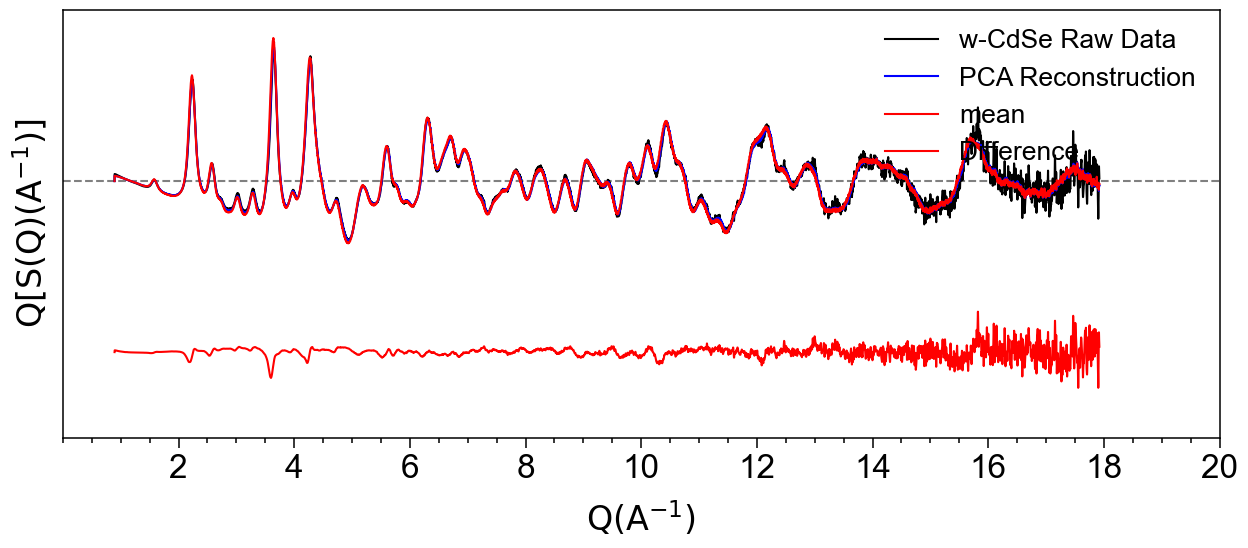

In [6]:

q = np.arange(0.894, df_cleaned.shape[1]*0.001+0.894, 0.001)
row_values = fq_reconstructed_df.iloc[0, :].values
original_values = df_cleaned.iloc[0, :].values
mean_values = fq_reconstructed_df.mean(axis=0)


fig, ax = plt.subplots(figsize = (13,6))

# Add two horizontal lines centered in each plot
ax.axhline(y=np.mean(mean_values * 1.8), color='gray', linestyle='--')

ax.plot(q, original_values, label="w-CdSe Raw Data")
ax.plot(q, row_values, label='PCA Reconstruction')
ax.plot(q, mean_values, label='mean')
ax.plot(q, original_values-mean_values-10, label='Difference', color = 'red')

# Set labels, limits, and ticks
ax.set_ylabel(r"$\mathrm{Q[S(Q) (A^{-1})]}$")
ax.set_xlabel(r"$\mathrm{Q (A^{-1})}$")
ax.set_xticks(np.arange(2, 21, step=2))
ax.set_yticks([])



# Create legend (initial position)
legend = ax.legend(fontsize=19, frameon=False,  bbox_to_anchor=(0.5, 0.51, 0.5, 0.5))


plt.tight_layout()
#plt.savefig('/home/ABTLUS/victor.secco/data_processing/Imagens/B-MRS 2024/pca_fq.png', dpi = 600)
# Show the plot
plt.show()

In [8]:
data = pd.DataFrame(np.transpose(np.array((q, mean_values))))
data.rename(columns={0:'q',1:'fq'},inplace=True)

output_directory = '/home/ABTLUS/victor.secco/data_processing/EXP2PDF/DATA/fq'
output_file = 'fq_pca_In2O3_S4.csv'

output_path = os.path.join(output_directory,output_file)

data.to_csv(output_path, sep='\t', float_format="%.10f", index=False)

In [12]:
data

,q,fq
0,0.894,-3.019858e-32
1,0.895,3.915615e-01
2,0.896,3.903927e-01
3,0.897,3.892158e-01
4,0.898,3.880286e-01
...,...,...
17026,17.920,-1.169590e-01
17027,17.921,-1.004546e-01
17028,17.922,-9.873461e-02
17029,17.923,-1.124359e-01
